In [ ]:
pip install "numpy<2" --force-reinstall

In [ ]:
pip install --upgrade matplotlib

In [1]:
import numpy as np

In [2]:
x=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
])
y=np.array([0,0,0,1])

In [3]:
w1=np.random.rand()
w2=np.random.rand()
b=np.zeros(1)

In [4]:
lr=0.1
epochs=10

In [5]:
def step_function(z):
    if z>=0:
        return 1
    else:
        return 0
    

In [6]:
for epoch in range(epochs):
    for i in range(len(x)):
        z=w1*x[i][0]+w2*x[i][1]+b
        y_pred=step_function(z)
        
        error=y[i]-y_pred
        
        w1+=lr*error*x[i][0]
        w2+=lr*error*x[i][1]
        b+=lr*error
print("Weight 1:",w1)
print("Weight 2:",w2)
print("Bais :",b)



    

Weight 1: 0.29399940044438455
Weight 2: 0.16271992675003188
Bais : [-0.4]


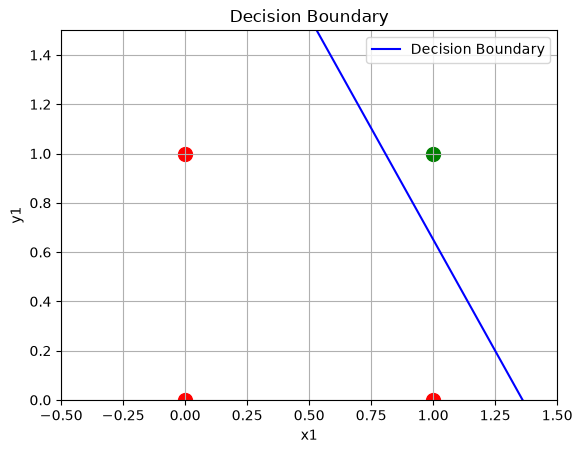

In [7]:
import matplotlib.pyplot as plt
w=np.array([w1,w2])
for i in range(len(x)):
    if y[i]==0:
        plt.scatter(x[i][0],x[i][1],color='red',s=100)
    else:
        plt.scatter(x[i][0],x[i][1],color='green',s=100)
# Decision Boundary = w0*x1+w1*x2+b=0

x_vals=np.array([-0.5,1.5])

if w[1]!=0:
    y_vals=-(w[0]*x_vals+b)/w[1]
    plt.plot(x_vals,y_vals,"b-",label="Decision Boundary")
else:
    plt.plot(x=-b/w[0],color="blue",label="Decision Boundary")

plt.xlim(-0.5,1.5)
plt.ylim(0,1.5)
plt.xlabel("x1")                    
plt.ylabel("y1")
plt.title("Decision Boundary")
plt.grid(True)
plt.legend()
plt.show()

In [8]:
class Perceptrone:
    def __init__(self,input_size,lr=0.1,epochs=10)->None:
        self.w=np.random.rand(input_size)
        self.b=0.0
        self.lr=lr
        self.epochs=epochs
        
    def step_function(self,z)->int:
        if z>0:
            return 1
        return 0
    
    def forward(self,x)->int:
        a=np.dot(x,self.w)+self.b
        return self.step_function(a)
    
    def fit(self,x,y)->None:
        for epoch in range(self.epochs):
            for i in range(len(x)):
                y_pred=self.forward(x[i])
                
                error=y[i]-y_pred
                self.w+=self.lr*error*x[i]
                self.b+=self.lr*error


In [9]:
perceptrone = Perceptrone(2,0.1,10)
perceptrone.fit(x,y)

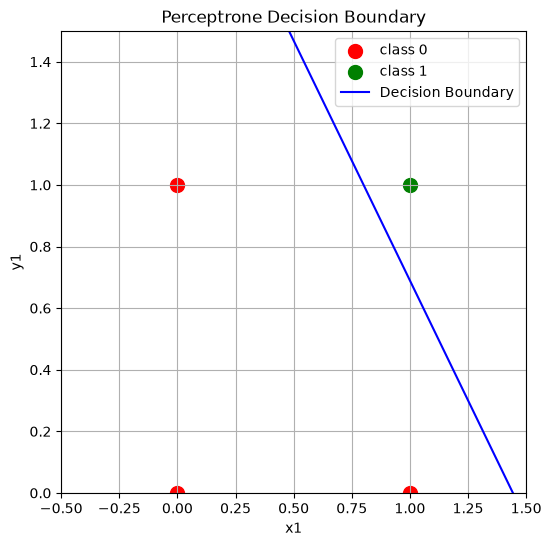

In [10]:
plt.figure(figsize=(6,6))
for i in range(len(x)):
    if y[i]==0:
        plt.scatter(x[i][0],x[i][1],color='red',s=100,label="class 0" if i==0 else"")
    else:
        plt.scatter(x[i][0],x[i][1],color='green',s=100,label="class 1" if i==3 else"")
           
#Extract weights
w=perceptrone.w
b=perceptrone.b           
# Decision Boundary = w0*x1+w1*x2+b=0

x_vals=np.array([-0.5,1.5])

if w[1]!=0:
    y_vals=-(w[0]*x_vals+b)/w[1]
    plt.plot(x_vals,y_vals,"b-",label="Decision Boundary")
else:
    plt.plot(x=-b/w[0],color="blue",label="Decision Boundary")

plt.xlim(-0.5,1.5)
plt.ylim(0,1.5)
plt.xlabel("x1")                    
plt.ylabel("y1")
plt.title("Perceptrone Decision Boundary")
plt.grid(True)
plt.legend()
plt.show()